## CALCULATE THE DISTANCE BETWEEN THE ORIGINAL, THE RANDOM and OUR GENERATOR

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder
from scipy.spatial import distance
from sklearn.manifold import TSNE

import altair as alt
alt.data_transformers.enable('default', max_rows=None)

DataTransformerRegistry.enable('default')

In [2]:
## import the ordinal encoded dataset
df = pd.read_csv('../../datasets/enc_dataset.csv')
df_ourgen = pd.read_csv('../../datasets/ordinal_neighbourhood.csv')

In [3]:
#import the one-hot-encoded random df
df_random=pd.read_csv('../../datasets/random_n_dataset.csv')
df_random.head()

,Week6_Covid=NONE,Week6_Covid=AND,Week6_Covid=LMM,Week6_Covid=HM,Week6_Covid=HMM,Week5_Covid=NONE,Week5_Covid=AND,Week5_Covid=LMM,Week5_Covid=HM,Week5_Covid=HMM,...,Week2_Mobility=NONE,Week2_Mobility=NM,Week2_Mobility=SH,Week2_Mobility=DM,Week2_Mobility=IM,Week1_Mobility=NONE,Week1_Mobility=NM,Week1_Mobility=SH,Week1_Mobility=DM,Week1_Mobility=IM
0,0,0,0,0,1,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0,0
1,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,1,0,1,0,0,0
2,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,1,1,0,0,0,0
3,0,1,0,0,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0
4,1,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0


In [4]:
df=df.drop("Class_label", axis=1)

In [5]:
df= df.astype(int)

In [6]:
df.head()

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility
0,1,1,0,0,0,0,1,1,0,0,0,0
1,1,1,1,1,1,1,1,1,1,1,1,1
2,2,2,2,2,2,2,2,3,3,3,3,3
3,0,0,0,1,1,1,0,0,0,1,1,1
4,1,1,1,1,1,1,1,1,1,1,1,1


In [7]:
data_np=df.to_numpy()

#### Change the one hot encoded structure df

In [8]:
# Initialize an empty DataFrame
decoded_random_df = pd.DataFrame(index=df_random.index)

# Loop over each column and process
for column in df_random.columns:
    col_name, col_value = column.split('=')  # Split the column name

    
    # Check where the original DataFrame has a 1 (i.e., is 'hot'), and set that value
    decoded_random_df.loc[df_random[column] == 1, col_name] = col_value
decoded_random_df.head()

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility
0,HMM,HM,AND,LMM,AND,NONE,NM,DM,NONE,IM,NONE,SH
1,HM,LMM,AND,LMM,HMM,HMM,NM,IM,SH,DM,IM,NM
2,AND,HMM,AND,NONE,NONE,HM,DM,SH,IM,NONE,IM,NONE
3,AND,HM,HM,LMM,AND,LMM,SH,NONE,NONE,SH,NONE,NONE
4,NONE,NONE,HMM,LMM,HMM,HMM,SH,DM,NM,SH,DM,DM


In [9]:
#### Ordinal encode the random df

covid_categories = ['NONE', 'AND', 'LMM', 'HM', 'HMM']
mobility_categories = ['NONE', 'NM', 'DM', 'SH', 'IM']

enc = OrdinalEncoder(categories=[covid_categories for i in range(6)] + [mobility_categories for i in range(6)])
 
enc_random= enc.fit_transform(decoded_random_df)

enc_random_df = pd.DataFrame(enc_random)
enc_random_df.columns = [df.columns]

In [10]:
enc_random_df.head()

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility
0,4.0,3.0,1.0,2.0,1.0,0.0,1.0,2.0,0.0,4.0,0.0,3.0
1,3.0,2.0,1.0,2.0,4.0,4.0,1.0,4.0,3.0,2.0,4.0,1.0
2,1.0,4.0,1.0,0.0,0.0,3.0,2.0,3.0,4.0,0.0,4.0,0.0
3,1.0,3.0,3.0,2.0,1.0,2.0,3.0,0.0,0.0,3.0,0.0,0.0
4,0.0,0.0,4.0,2.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,2.0


In [11]:
enc_random_df= enc_random_df.astype(int)

In [12]:
enc_random_np=enc_random_df.to_numpy()

In [13]:
df_ourgen.head()

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility
0,3,2,2,1,3,4,3,4,4,4,4,4
1,3,2,1,2,3,2,3,3,2,3,4,4
2,1,1,2,2,1,1,2,2,1,1,4,3
3,3,1,3,3,1,4,1,1,1,1,2,2
4,1,4,3,3,2,3,1,1,2,3,3,2


In [14]:
ourgen_np=df_ourgen.to_numpy()

In [15]:
ourgen_np

array([[3, 2, 2, ..., 4, 4, 4],
       [3, 2, 1, ..., 3, 4, 4],
       [1, 1, 2, ..., 1, 4, 3],
       ...,
       [1, 3, 3, ..., 2, 2, 1],
       [1, 3, 4, ..., 1, 1, 2],
       [3, 3, 3, ..., 4, 2, 2]])

### COMPUTE THE DISTANCE

In [16]:
#Distances between original data and generates neigh
dist_matrix = distance.cdist(data_np, ourgen_np, 'euclidean')

# Find the index of the closest vector in generates neigh for each vector in the original data
closest_indices = np.argmin(dist_matrix, axis=1)
closest_vectors = ourgen_np[closest_indices]

In [17]:
similarity_scores = np.sum(dist_matrix, axis=0)

In [18]:
similarity_scores

array([2824.39315214, 2311.41609795, 2031.01972236, 1835.39023441,
       1962.85821829, 2006.92080179, 1996.72830378, 2076.00590575,
       2292.71166367, 1756.64578747, 1735.39083812, 2508.25896125,
       2286.19399483, 1862.73471526, 2450.96178494, 2204.47854669,
       1735.7352941 , 1988.19304579, 2393.84713047, 2585.39063346,
       2457.87735866, 1849.68546167, 2219.50126347, 2013.48457773,
       2201.43622508, 2270.55701157, 2070.93914844, 1848.13139355,
       1802.01889259, 2236.49407054, 1649.33085761, 2150.54172873,
       2037.89322511, 2371.49498292, 2418.33164814, 2614.33405099,
       2039.74492528, 2053.52654261, 2149.93694208, 1694.18624333,
       2402.05985978, 2455.87699672, 1806.5880331 , 2014.5215784 ,
       2319.47516497, 1954.56641227, 2019.6642393 , 1913.74634248,
       1624.18513678, 1613.17533978, 2272.16429706, 1747.7813204 ,
       2362.93306585, 2003.52804701, 2099.2276264 , 1957.38718736,
       2485.8607265 , 2466.28644677, 2234.65200926, 2978.47053

In [19]:
sorted_indices = np.argsort(similarity_scores)
m3 = ourgen_np[sorted_indices[::-1]]  # m3 is m2 sorted by decreasing similarity

In [20]:
m3

array([[2, 2, 3, ..., 4, 4, 4],
       [3, 2, 2, ..., 4, 4, 4],
       [3, 3, 3, ..., 4, 4, 1],
       ...,
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 2, ..., 1, 1, 3],
       [2, 2, 2, ..., 2, 2, 1]])

In [29]:
#Distances between original data and generates neigh
dist_matrix_r = distance.cdist(data_np, enc_random_np, 'euclidean')

# Find the index of the closest vector in generates neigh for each vector in the original data
closest_indices = np.argmin(dist_matrix, axis=1)
closest_vectors_r = enc_random_np[closest_indices]

In [30]:
similarity_scores_r = np.sum(dist_matrix_r, axis=0)

In [31]:
similarity_scores_r

array([2464.92343218, 2392.97822861, 2761.52536644, 2167.46016426,
       2397.16481706, 2619.36208839, 1944.76000911, 2543.47489384,
       2065.2181087 , 1941.99377964, 2393.93612407, 2539.6583562 ,
       2327.99881959, 2687.91147586, 2828.32298067, 2398.73180717,
       2543.93001293, 2498.27433733, 2410.59286347, 1884.87631093,
       2057.96940199, 2444.4817595 , 2724.63751271, 2723.23025248,
       2671.30490681, 1937.23689234, 2326.85311182, 2567.84228835,
       2116.44506729, 2339.36521865, 2477.18581639, 2658.62186982,
       2108.48209401, 2285.91441129, 2788.06745537, 2183.50306948,
       2929.54684917, 2540.31206095, 2401.17395387, 2384.29560544,
       2714.04494797, 2078.33728551, 2486.03862068, 2396.39037777,
       2573.99544281, 2368.62864203, 3011.01673823, 2412.11873024,
       2650.78721438, 2770.24756006, 2347.2684273 , 1909.19810248,
       2113.43073605, 2276.27995324, 2624.46733674, 2150.9843234 ,
       2215.25255009, 2333.5082065 , 2759.66581116, 2649.22492

In [32]:
sorted_indices_r = np.argsort(similarity_scores_r)
m4 = enc_random_np[sorted_indices_r[::-1]]  # m3 is m2 sorted by decreasing similarity

In [33]:
m4

array([[0, 0, 0, ..., 4, 4, 0],
       [4, 3, 4, ..., 3, 4, 0],
       [4, 0, 3, ..., 4, 4, 4],
       ...,
       [2, 1, 2, ..., 2, 1, 1],
       [3, 3, 1, ..., 1, 2, 1],
       [3, 1, 2, ..., 2, 2, 1]])

### TSNE

In [35]:
tsne = TSNE(n_components=2, random_state=42)  # n_components means the lower dimension

X_embedded_1 = tsne.fit_transform(data_np)
X_embedded_2 = tsne.fit_transform(enc_random_np)
X_embedded_3 = tsne.fit_transform(ourgen_np) 

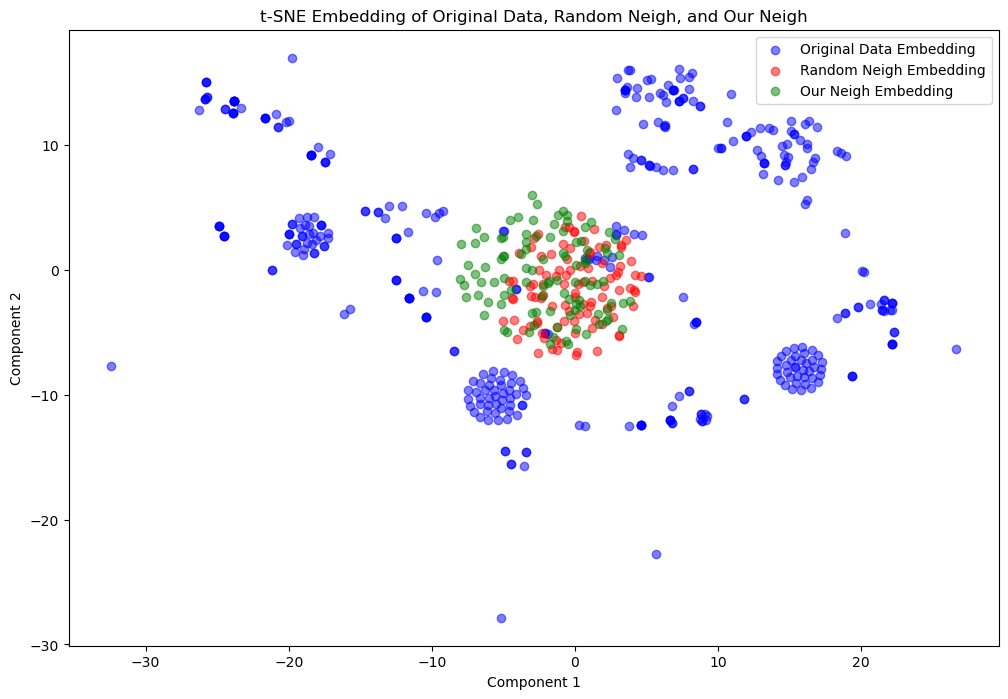

In [36]:
plt.figure(figsize=(12, 8))

# Plot each array's embedding with different colors
plt.scatter(X_embedded_1[:, 0], X_embedded_1[:, 1], c='blue', label='Original Data Embedding', alpha=0.5)
plt.scatter(X_embedded_2[:, 0], X_embedded_2[:, 1], c='red', label='Random Neigh Embedding', alpha=0.5)
plt.scatter(X_embedded_3[:, 0], X_embedded_3[:, 1], c='green', label='Our Neigh Embedding', alpha=0.5)

plt.title('t-SNE Embedding of Original Data, Random Neigh, and Our Neigh')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend()
plt.show()

### OLD STUFF

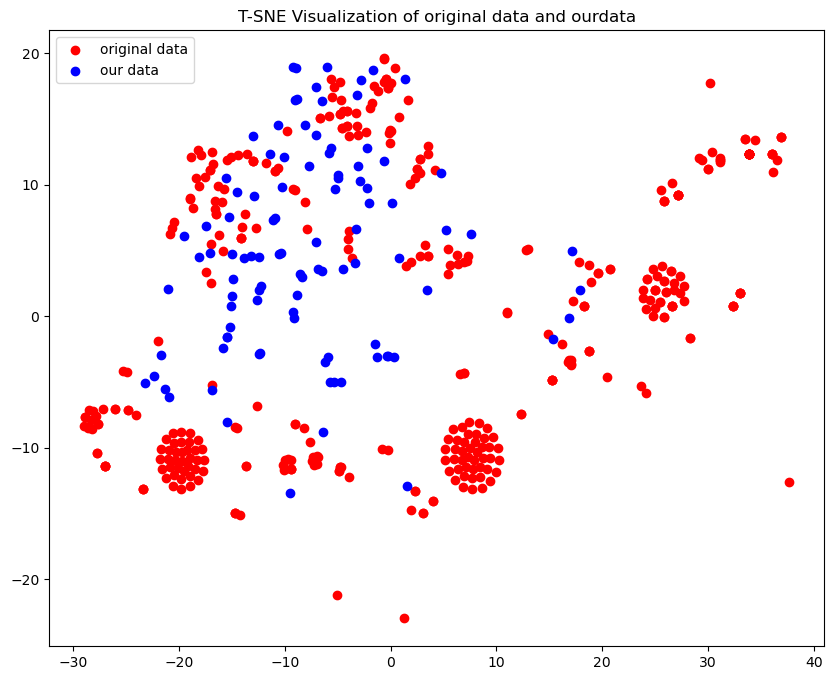

In [22]:
'''
# Combine two np
combined_data = np.vstack((data_np, ourgen_np,))

# Perform T-SNE
tsne = TSNE(n_components=2, random_state=0)
transformed_data = tsne.fit_transform(combined_data)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(transformed_data[:len(data_np), 0], transformed_data[:len(data_np), 1], color='red', label='original data')
plt.scatter(transformed_data[len(data_np):, 0], transformed_data[len(data_np):, 1], color='blue', label='our data')
plt.legend()
plt.title('T-SNE Visualization of original data and ourdata')
plt.show()
'''

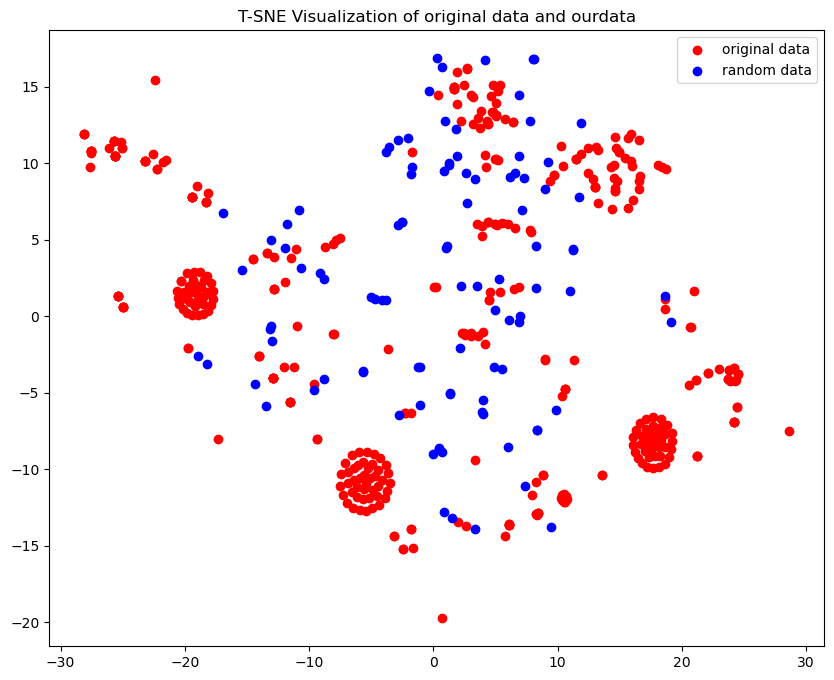

In [23]:
'''
# Combine two np
combined_data = np.vstack((data_np, enc_random_np))

# Perform T-SNE
tsne = TSNE(n_components=2, random_state=0)
transformed_data = tsne.fit_transform(combined_data)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(transformed_data[:len(data_np), 0], transformed_data[:len(data_np), 1], color='red', label='original data')
plt.scatter(transformed_data[len(data_np):, 0], transformed_data[len(data_np):, 1], color='blue', label='random data')
plt.legend()
plt.title('T-SNE Visualization of original data and ourdata')
plt.show()
'''